# Đánh giá các kỹ thuật Feature Selection với SVM, XGBoost và RandomForest
Notebook này dùng dữ liệu đã tiền xử lý theo `Tien_xu_ly_du_lieu.ipynb` (đã loại Id 524, 1299; biến mục tiêu `log1p(SalePrice)`).

**Thiết kế thực nghiệm**
- Chia hold-out 80/20 (`random_state=42`). Toàn bộ so sánh dùng 5-fold CV trên 80% huấn luyện; phần 20% chỉ dùng để kiểm tra lại một lần.
- Tiền xử lý, Feature Selection và mô hình đều được fit **riêng trong từng fold** (không rò rỉ dữ liệu).
- Chín cấu hình: Baseline (229 đặc trưng) và 8 kỹ thuật thuộc Filter (Variance, Correlation, F-test, Mutual Info), Wrapper (RFE-Ridge), Embedded (Lasso, RF importance, XGB importance).
- Ba mô hình với siêu tham số cố định giống nhau cho mọi cấu hình: SVM (SVR, RBF), RandomForest, XGBoost.
- Chỉ số: RMSE trên thang log (tương đương RMSLE của Kaggle), R², MAE theo USD, số đặc trưng, thời gian.

In [1]:
import json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from tien_xu_ly import *
from chon_dac_trung import *
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

train, test = doc_du_lieu('train.csv', 'test.csv')
train = loai_mau_bat_thuong(train)
y = np.log1p(train['SalePrice'])
df_tr, df_ho, y_tr, y_ho = train_test_split(train, y, test_size=0.2, random_state=SEED)
df_tr, df_ho, y_tr, y_ho = df_tr.reset_index(drop=True), df_ho.reset_index(drop=True), y_tr.reset_index(drop=True), y_ho.reset_index(drop=True)
print('Huấn luyện (CV):', df_tr.shape, '| Hold-out:', df_ho.shape)
print('Kỹ thuật:', SELECTORS); print('Mô hình:', MODELS)

Huấn luyện (CV): (1166, 81) | Hold-out: (292, 81)
Kỹ thuật: ['Baseline (tất cả)', 'Variance', 'Correlation', 'F-test', 'Mutual Info', 'RFE (Ridge)', 'Lasso', 'RF importance', 'XGB importance']
Mô hình: ['SVM', 'RandomForest', 'XGBoost']


## 1. Cross-validation 5 fold
Mỗi fold: fit tiền xử lý -> fit selector -> fit 3 mô hình -> chấm điểm trên phần validation.

In [2]:
t0 = time.time()
cv_raw, cv_kept = cross_validate_fs(df_tr, y_tr, n_splits=5)
print(f'Tổng thời gian CV: {time.time()-t0:.0f}s')
cv_raw.to_csv('ket_qua/cv_tung_fold.csv', index=False, encoding='utf-8-sig')

agg = cv_raw.groupby(['Selector','Nhom','Model']).agg(
    RMSE_log=('RMSE_log','mean'), RMSE_std=('RMSE_log','std'), R2=('R2','mean'), MAE_USD=('MAE_USD','mean'),
    So_dac_trung=('So_dac_trung','mean'), T_chon=('Thoi_gian_chon','mean'), T_fit=('Thoi_gian_fit','mean')).reset_index()
agg.to_csv('ket_qua/cv_tong_hop.csv', index=False, encoding='utf-8-sig')
pv = agg.pivot(index='Selector', columns='Model', values='RMSE_log').reindex(SELECTORS)[MODELS]
pv['Trung bình'] = pv.mean(axis=1)
nfeat = agg.groupby('Selector')['So_dac_trung'].mean().reindex(SELECTORS).round(0).astype(int)
pv.insert(0, 'Số đặc trưng', nfeat)
pv.round(4)

  fold 1/5 xong


  fold 2/5 xong


  fold 3/5 xong


  fold 4/5 xong


  fold 5/5 xong


Tổng thời gian CV: 108s


Model,Số đặc trưng,SVM,RandomForest,XGBoost,Trung bình
Selector,,,,,
Baseline (tất cả),219,0.1094,0.1305,0.1136,0.1179
Variance,179,0.1090,0.1303,0.1147,0.1180
Correlation,111,0.1178,0.1314,0.1189,0.1227
F-test,60,0.1255,0.1331,0.1278,0.1288
Mutual Info,60,0.1205,0.1309,0.1226,0.1247
RFE (Ridge),60,0.1151,0.1329,0.1194,0.1225
Lasso,101,0.1112,0.1291,0.1143,0.1182
RF importance,20,0.1242,0.1337,0.1248,0.1276
XGB importance,24,0.1303,0.1337,0.1291,0.1310


### R² và MAE (USD)

In [3]:
r2 = agg.pivot(index='Selector', columns='Model', values='R2').reindex(SELECTORS)[MODELS].round(4)
mae = agg.pivot(index='Selector', columns='Model', values='MAE_USD').reindex(SELECTORS)[MODELS].round(0).astype(int)
display(r2); display(mae)

Model,SVM,RandomForest,XGBoost
Selector,,,
Baseline (tất cả),0.9227,0.8910,0.9174
Variance,0.9233,0.8914,0.9156
Correlation,0.9106,0.8896,0.9094
F-test,0.8985,0.8866,0.8954
Mutual Info,0.9065,0.8904,0.9037
RFE (Ridge),0.9145,0.8867,0.9083
Lasso,0.9204,0.8934,0.9161
RF importance,0.9008,0.8856,0.9002
XGB importance,0.8904,0.8857,0.8929


Model,SVM,RandomForest,XGBoost
Selector,,,
Baseline (tất cả),13250,16152,13946
Variance,13164,16158,13846
Correlation,14224,16252,14531
F-test,15072,16562,15727
Mutual Info,14523,16141,15111
RFE (Ridge),13821,16720,14669
Lasso,13370,16052,13805
RF importance,15055,16672,15454
XGB importance,15953,16740,16198


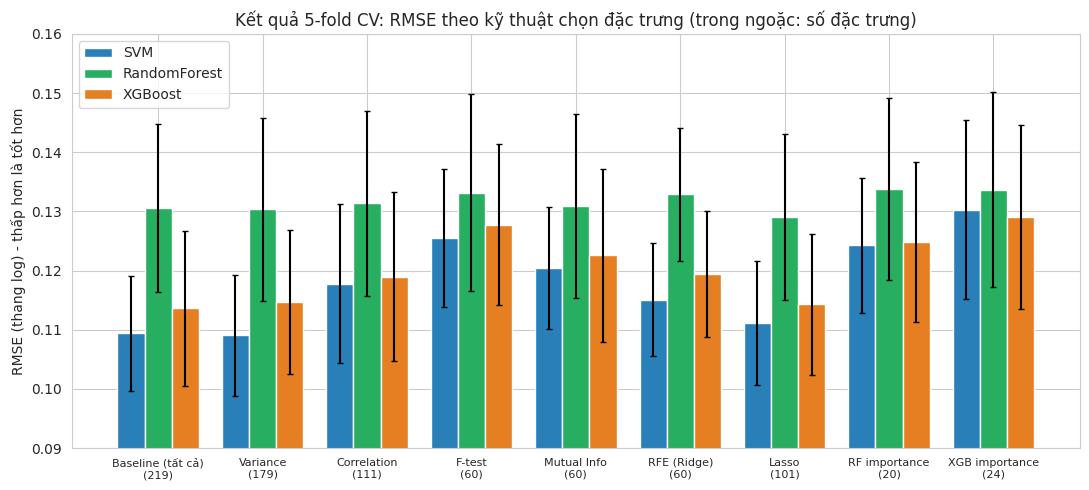

In [4]:
fig, ax = plt.subplots(figsize=(11,5))
w = 0.26; xs = np.arange(len(SELECTORS))
cols = {'SVM':'#2980b9','RandomForest':'#27ae60','XGBoost':'#e67e22'}
for j, m in enumerate(MODELS):
    sub = agg[agg.Model==m].set_index('Selector').reindex(SELECTORS)
    ax.bar(xs + (j-1)*w, sub['RMSE_log'], w, yerr=sub['RMSE_std'], capsize=2, label=m, color=cols[m])
ax.set_xticks(xs); ax.set_xticklabels([f'{s}\n({n})' for s, n in zip(SELECTORS, nfeat)], fontsize=8, rotation=0)
ax.set_ylim(0.09, 0.16); ax.set_ylabel('RMSE (thang log) - thấp hơn là tốt hơn'); ax.set_title('Kết quả 5-fold CV: RMSE theo kỹ thuật chọn đặc trưng (trong ngoặc: số đặc trưng)')
ax.legend(); plt.tight_layout(); plt.savefig('hinh/h5_cv_rmse.png', dpi=150); plt.show()

### Xếp hạng trung bình và mức thay đổi so với Baseline

In [5]:
rank = pv[MODELS].rank(axis=0)
rank['Hạng TB'] = rank.mean(axis=1)
delta = ((pv[MODELS].sub(pv.loc['Baseline (tất cả)', MODELS], axis=1)) / pv.loc['Baseline (tất cả)', MODELS] * 100).round(1)
summary = pd.concat([pv[['Số đặc trưng']], rank[MODELS].add_prefix('Hạng '), rank[['Hạng TB']].round(2), delta.add_prefix('Δ% ')], axis=1)
summary.to_csv('ket_qua/xep_hang.csv', encoding='utf-8-sig')
summary

Model,Số đặc trưng,Hạng SVM,Hạng RandomForest,Hạng XGBoost,Hạng TB,Δ% SVM,Δ% RandomForest,Δ% XGBoost
Selector,,,,,,,,
Baseline (tất cả),219,2.0,3.0,1.0,2.00,0.0,0.0,0.0
Variance,179,1.0,2.0,3.0,2.00,-0.3,-0.2,1.0
Correlation,111,5.0,5.0,4.0,4.67,7.7,0.6,4.7
F-test,60,8.0,7.0,8.0,7.67,14.7,2.0,12.5
Mutual Info,60,6.0,4.0,6.0,5.33,10.1,0.3,7.9
RFE (Ridge),60,4.0,6.0,5.0,5.00,5.2,1.8,5.1
Lasso,101,3.0,1.0,2.0,2.00,1.6,-1.1,0.6
RF importance,20,7.0,9.0,7.0,7.67,13.6,2.4,9.8
XGB importance,24,9.0,8.0,9.0,8.67,19.1,2.4,13.7


### Thời gian chạy

In [6]:
tm = agg.assign(T=agg['T_chon']+agg['T_fit']).pivot(index='Selector', columns='Model', values='T').reindex(SELECTORS)[MODELS].round(2)
tsel = agg.groupby('Selector')['T_chon'].mean().reindex(SELECTORS).round(2).rename('Thời gian chọn (s)')
pd.concat([tsel, tm.add_prefix('Tổng (chọn+fit) ')], axis=1)

,Thời gian chọn (s),Tổng (chọn+fit) SVM,Tổng (chọn+fit) RandomForest,Tổng (chọn+fit) XGBoost
Selector,,,,
Baseline (tất cả),0.00,0.05,2.44,0.48
Variance,0.00,0.06,2.32,0.41
Correlation,0.16,0.21,1.91,0.47
F-test,0.00,0.07,1.45,0.26
Mutual Info,0.91,0.97,2.53,1.19
RFE (Ridge),0.02,0.06,1.02,0.20
Lasso,0.16,0.22,1.91,0.48
RF importance,2.39,2.44,3.38,2.56
XGB importance,0.20,0.25,1.00,0.33


## 2. Kiểm tra trên hold-out 20%
Fit trên toàn bộ 80% huấn luyện, chấm điểm một lần trên 20% chưa từng dùng.

In [7]:
ho_rows, ho_kept = danh_gia_mot_lan(df_tr, y_tr, df_ho, y_ho)
ho = pd.DataFrame(ho_rows); ho.to_csv('ket_qua/holdout.csv', index=False, encoding='utf-8-sig')
ho_pv = ho.pivot(index='Selector', columns='Model', values='RMSE_log').reindex(SELECTORS)[MODELS]
ho_pv.insert(0, 'Số đặc trưng', ho.groupby('Selector')['So_dac_trung'].first().reindex(SELECTORS))
ho_pv.round(4)

Model,Số đặc trưng,SVM,RandomForest,XGBoost
Selector,,,,
Baseline (tất cả),222,0.1159,0.1390,0.1136
Variance,179,0.1177,0.1389,0.1185
Correlation,112,0.1199,0.1415,0.1186
F-test,60,0.1332,0.1453,0.1364
Mutual Info,60,0.1218,0.1408,0.1249
RFE (Ridge),60,0.1207,0.1404,0.1174
Lasso,100,0.1132,0.1393,0.1131
RF importance,21,0.1192,0.1420,0.1286
XGB importance,19,0.1383,0.1516,0.1480


## 3. Ảnh hưởng của số đặc trưng k
Xếp hạng đặc trưng một lần bằng F-test, Mutual Information và RF importance, sau đó lấy top-k. Chạy trên 5 fold để lấy trung bình.

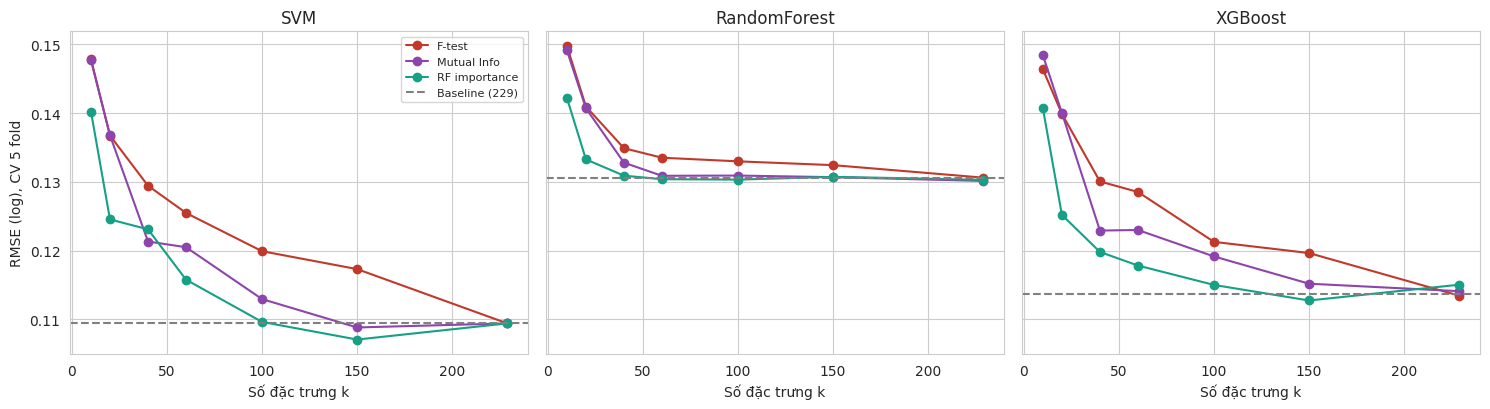

k                              10      20      40      60      100     150  \
Model        Selector                                                        
RandomForest F-test         0.1498  0.1410  0.1349  0.1335  0.1330  0.1324   
             Mutual Info    0.1491  0.1407  0.1328  0.1309  0.1309  0.1307   
             RF importance  0.1422  0.1333  0.1309  0.1304  0.1303  0.1307   
SVM          F-test         0.1479  0.1367  0.1294  0.1255  0.1199  0.1173   
             Mutual Info    0.1477  0.1368  0.1213  0.1205  0.1129  0.1088   
             RF importance  0.1402  0.1245  0.1231  0.1158  0.1096  0.1070   
XGBoost      F-test         0.1464  0.1399  0.1301  0.1285  0.1213  0.1196   
             Mutual Info    0.1484  0.1400  0.1229  0.1230  0.1191  0.1152   
             RF importance  0.1407  0.1252  0.1198  0.1178  0.1150  0.1127   

k                              229  
Model        Selector               
RandomForest F-test         0.1306  
             Mutual Info    0.1301  
             RF importance  0.1303  
SVM          F-test         0.1094  
             Mutual Info    0.1094  
             RF importance  0.1094  
XGBoost      F-test         0.1134  
             Mutual Info    0.1141  
             RF importance  0.1150

In [8]:
from sklearn.model_selection import KFold
ks = (10, 20, 40, 60, 100, 150, 229)
res = []
for i, (a, b) in enumerate(KFold(5, shuffle=True, random_state=SEED).split(df_tr)):
    r, _ = quet_k(df_tr.iloc[a], y_tr.iloc[a], df_tr.iloc[b], y_tr.iloc[b], ks=ks)
    res.append(r)
sweep = pd.concat(res).groupby(['Selector','k','Model'], as_index=False)['RMSE_log'].mean()
sweep.to_csv('ket_qua/quet_k.csv', index=False, encoding='utf-8-sig')
fig, axes = plt.subplots(1, 3, figsize=(15,4.2), sharey=True)
for ax, m in zip(axes, MODELS):
    for s, c in zip(['F-test','Mutual Info','RF importance'], ['#c0392b','#8e44ad','#16a085']):
        d = sweep[(sweep.Model==m)&(sweep.Selector==s)]
        ax.plot(d['k'], d['RMSE_log'], marker='o', label=s, color=c)
    ax.axhline(agg[(agg.Model==m)&(agg.Selector=='Baseline (tất cả)')]['RMSE_log'].iloc[0], color='gray', ls='--', label='Baseline (229)')
    ax.set_title(m); ax.set_xlabel('Số đặc trưng k')
axes[0].set_ylabel('RMSE (log), CV 5 fold'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig('hinh/h6_quet_k.png', dpi=150); plt.show()
sweep.pivot_table(index=['Model','Selector'], columns='k', values='RMSE_log').round(4)

## 4. Độ ổn định và nội dung các đặc trưng được chọn
Độ ổn định = Jaccard trung bình giữa các cặp fold. Bảng cuối cho biết đặc trưng nào được nhiều kỹ thuật chọn nhất và đối chiếu với Top 10 tương quan ở báo cáo EDA.

In [9]:
stab = pd.DataFrame({'Jaccard TB giữa các fold': {s: jaccard_on_dinh(cv_kept, s) for s in SELECTORS if s != 'Baseline (tất cả)'}}).round(3)
stab['Số đặc trưng TB'] = nfeat.reindex(stab.index)
stab.to_csv('ket_qua/on_dinh.csv', encoding='utf-8-sig'); stab

,Jaccard TB giữa các fold,Số đặc trưng TB
Variance,0.960,179
Correlation,0.864,111
F-test,0.964,60
Mutual Info,0.884,60
RFE (Ridge),0.478,60
Lasso,0.636,101
RF importance,0.799,20
XGB importance,0.598,24


In [10]:
from collections import Counter
prep = build_preprocessor(); Xf = prep.fit_transform(df_tr, y_tr)
final_sets = {}
for s in SELECTORS[1:]:
    sel = make_selector(s).fit(Xf, y_tr); final_sets[s] = set(sel.transform(Xf).columns)
cnt = Counter(f for v in final_sets.values() for f in v)
freq = pd.Series(cnt).sort_values(ascending=False)
print('Số đặc trưng được ít nhất 6/8 kỹ thuật chọn:', int((freq>=6).sum()))
top_freq = freq.head(20).rename('Số kỹ thuật chọn (/8)').to_frame()
eda_top10 = ['OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF','1stFlrSF','FullBath','TotRmsAbvGrd','YearBuilt','YearRemodAdd']
chk = pd.DataFrame({'Số kỹ thuật chọn (/8)': [cnt.get(f, 0) for f in eda_top10]}, index=eda_top10)
chk.to_csv('ket_qua/doi_chieu_eda_top10.csv', encoding='utf-8-sig'); top_freq.to_csv('ket_qua/dac_trung_pho_bien.csv', encoding='utf-8-sig')
display(top_freq); display(chk)

Số đặc trưng được ít nhất 6/8 kỹ thuật chọn: 25


,Số kỹ thuật chọn (/8)
HouseAge,8
BsmtQual,8
OverallQual,8
TotalSF,8
TotalBath,8
GarageArea,8
RemodAge,7
CentralAir,7
LotArea,7
TotalBsmtSF,7


,Số kỹ thuật chọn (/8)
OverallQual,8
GrLivArea,7
GarageCars,7
GarageArea,8
TotalBsmtSF,7
1stFlrSF,6
FullBath,4
TotRmsAbvGrd,5
YearBuilt,5
YearRemodAdd,4


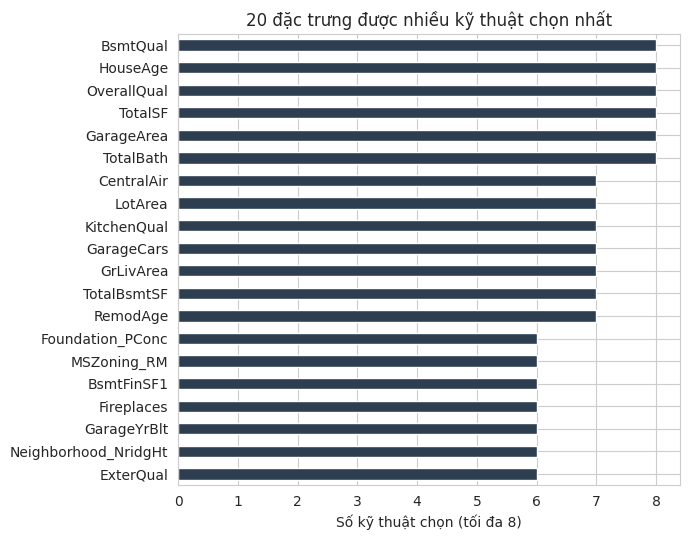

In [11]:
fig, ax = plt.subplots(figsize=(7,5.5))
top_freq.sort_values('Số kỹ thuật chọn (/8)').plot(kind='barh', legend=False, color='#2c3e50', ax=ax)
ax.set_title('20 đặc trưng được nhiều kỹ thuật chọn nhất'); ax.set_xlabel('Số kỹ thuật chọn (tối đa 8)')
plt.tight_layout(); plt.savefig('hinh/h7_dac_trung_pho_bien.png', dpi=150); plt.show()

## 5. Chọn cấu hình tốt nhất và tạo file nộp bài
Cấu hình được chọn theo **RMSE CV trung bình** (không dùng hold-out để chọn). Sau đó huấn luyện lại trên toàn bộ 1458 mẫu và dự đoán `test.csv`, xuất theo định dạng `sample_submission.csv`.

In [12]:
best_per_model = agg.loc[agg.groupby('Model')['RMSE_log'].idxmin(), ['Model','Selector','So_dac_trung','RMSE_log','R2']]
print(best_per_model.round(4).to_string(index=False))
best = agg.loc[agg['RMSE_log'].idxmin()]
print('\nCấu hình tốt nhất toàn cục (CV):', best['Selector'], '+', best['Model'], f"| RMSE_log = {best['RMSE_log']:.4f}")
best_per_model.to_csv('ket_qua/cau_hinh_tot_nhat.csv', index=False, encoding='utf-8-sig')

# Ensemble đơn giản: trung bình dự đoán của cấu hình tốt nhất của từng mô hình (chỉ để tham khảo, đánh giá trên hold-out)
def fit_predict(df_a, y_a, df_b, sname, mname):
    p = build_preprocessor(); A = p.fit_transform(df_a, y_a); B = p.transform(df_b)
    sel = make_selector(sname)
    if sel is not None:
        sel.fit(A, y_a); A, B = sel.transform(A), sel.transform(B)
    return make_model(mname).fit(A, y_a).predict(B)

ho_preds = {r.Model: fit_predict(df_tr, y_tr, df_ho, r.Selector, r.Model) for r in best_per_model.itertuples()}
rm = lambda p: float(np.sqrt(np.mean((p - y_ho)**2)))
ens_ho = rm(np.mean(list(ho_preds.values()), axis=0))
print({k: round(rm(v),4) for k, v in ho_preds.items()}, '| ensemble 3 mô hình (hold-out):', round(ens_ho,4))

       Model          Selector  So_dac_trung  RMSE_log     R2
RandomForest             Lasso         101.2    0.1291 0.8934
         SVM          Variance         178.8    0.1090 0.9233
     XGBoost Baseline (tất cả)         219.4    0.1136 0.9174

Cấu hình tốt nhất toàn cục (CV): Variance + SVM | RMSE_log = 0.1090


{'RandomForest': 0.1393, 'SVM': 0.1177, 'XGBoost': 0.1136} | ensemble 3 mô hình (hold-out): 0.1174


In [13]:
test_preds = {r.Model: fit_predict(train, y, test, r.Selector, r.Model) for r in best_per_model.itertuples()}
final_log = np.mean(list(test_preds.values()), axis=0)
sub = pd.read_csv('sample_submission.csv')
assert (sub['Id'].values == test['Id'].values).all()
sub['SalePrice'] = np.expm1(final_log)
sub.to_csv('submission.csv', index=False)
print(sub.shape, '| SalePrice min/median/max:', int(sub.SalePrice.min()), int(sub.SalePrice.median()), int(sub.SalePrice.max()))
json.dump({'ensemble_holdout_rmse': ens_ho, 'best_global': {'selector': best['Selector'], 'model': best['Model'], 'rmse': float(best['RMSE_log'])},
           'ho_best_per_model': {k: rm(v) for k, v in ho_preds.items()}}, open('ket_qua/tom_tat_danh_gia.json','w'), ensure_ascii=False, indent=1)
sub.head()

(1459, 2) | SalePrice min/median/max: 48291 157491 755894


,Id,SalePrice
0,1461,121219.514708
1,1462,159928.726625
2,1463,181498.327390
3,1464,191412.736078
4,1465,190577.907655
